---

# SundaLife

*Visualisasi Data Kemiskinan Jawa Barat 2021-2025*

---

## Kelompok 01 - IF4061 Visualisasi Data

- 13523004 - Razi Rachman Widyadhana
- 13523006 - William Andrian Dharma T
- 13523086 - Bob Kunanda
- 13523103 - Steven Owen Liauw
- 13523109 - Haegen Quinston

---

## Daftar Isi

1. [**Pendahuluan**](#1)
2. [**Inisialisasi**](#2)
3. [**Persiapan Data**](#3)
4. [**Transformasi Data**](#4)
5. [**Grafik 1: Tren Kemiskinan Pulau Jawa 2021-2025**](#5)
6. [**Grafik 2: Peta Sebaran Kemiskinan Jawa Barat**](#6)
7. [**Grafik 3: Korelasi Kemiskinan dan Pengangguran**](#7)
8. [**Grafik 4: Kota-Kota Anomali**](#8)


---

# Pendahuluan <a name="1"></a>

---

Jawa Barat merupakan provinsi dengan jumlah penduduk terbesar di Indonesia, namun menyimpan disparitas kemiskinan yang signifikan antarwilayah. Pola kemiskinan di tingkat kabupaten/kota memperlihatkan dinamika yang berbeda dari gambaran agregat provinsi, dan perlu ditelusuri secara lebih rinci.

Analisis ini menelusuri empat pertanyaan: bagaimana posisi Jawa Barat dibandingkan provinsi lain di Pulau Jawa selama 2021-2025, di mana kemiskinan paling terkonsentrasi di tingkat kabupaten/kota, seberapa kuat hubungan antara kemiskinan dan pengangguran, serta wilayah mana yang memperlihatkan pola berbeda dari mayoritas.

---

# Inisialisasi <a name="2"></a>

---

`geopandas` digunakan untuk membaca batas wilayah dari file GeoJSON GADM 4.1 dan memplot peta koropleth. Seluruh impor diletakkan dalam satu sel.

In [10]:
# %pip install geopandas --quiet

In [11]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats

%matplotlib inline

DATA_DIR   = '../data/'
RAW_DIR    = DATA_DIR + 'raw/'
CLEAN_DIR  = DATA_DIR + 'clean/'
OUTPUT_DIR = '../docs/output/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

---

# Persiapan Data <a name="3"></a>

---

Tahap ini membaca data mentah dari BPS dan menghasilkan dua file bersih di `data/clean/`. Seluruh logika pembersihan disertakan agar pipeline dapat direproduksi tanpa bergantung pada file bersih yang sudah tersimpan sebelumnya.

## Tren Kemiskinan Pulau Jawa

Setiap file tahunan BPS menggunakan format yang seragam: empat baris header, diikuti kolom nama provinsi, Semester 1, dan Semester 2. Nilai Semester 2 dipakai sebagai acuan utama, dengan *fallback* ke Semester 1 apabila tidak tersedia.

In [12]:
YEARS = [2021, 2022, 2023, 2024, 2025]
JAWA  = [
    'JAWA BARAT', 'JAWA TENGAH', 'JAWA TIMUR',
    'DKI JAKARTA', 'BANTEN', 'DI YOGYAKARTA',
]

processed = []
for year in YEARS:
    df = pd.read_csv(RAW_DIR + f'ppo_indonesia_{year}.csv', skiprows=4)
    df = df.iloc[:, [0, 1, 2]]
    df.columns = ['Provinsi', 'S1', 'S2']
    df['Provinsi'] = df['Provinsi'].str.strip()
    df = df[df['Provinsi'].isin(JAWA)].copy()
    df['S1'] = pd.to_numeric(df['S1'], errors='coerce')
    df['S2'] = pd.to_numeric(df['S2'], errors='coerce')
    df[str(year)] = df['S2'].fillna(df['S1'])
    processed.append(df[['Provinsi', str(year)]])

ppo_jawa = processed[0]
for df in processed[1:]:
    ppo_jawa = ppo_jawa.merge(df, on='Provinsi', how='outer')

ppo_jawa.to_csv(CLEAN_DIR + 'ppo_jawa_2021-2025.csv', index=False, encoding='utf-8')
print(ppo_jawa.to_string(index=False))

     Provinsi  2021  2022  2023  2024  2025
       BANTEN  6.04  5.89  6.00  5.57  5.35
DI YOGYAKARTA 11.20 10.64 10.27 10.11  9.99
  DKI JAKARTA  4.67  4.61  4.44  4.14  4.03
   JAWA BARAT  7.48  7.52  7.19  6.65  6.66
  JAWA TENGAH 10.16 10.02  9.78  8.83  8.99
   JAWA TIMUR  7.99  7.78  7.50  6.83  6.93


## Data Kabupaten/Kota Jawa Barat

Tiga file BPS untuk 2025 digabungkan menjadi satu tabel berisi persentase penduduk miskin, tingkat pengangguran terbuka, dan garis kemiskinan per kabupaten/kota. Baris agregat provinsi dibuang karena analisis berfokus pada level wilayah individual.

In [13]:
def clean_bps(path, col):
    df = pd.read_csv(path, header=None).iloc[:, :2]
    df.columns = ['region', col]
    df['region'] = df['region'].astype(str).str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=['region', col])
    return df[~df['region'].str.contains('Provinsi', na=False)]

jabar_raw = (
    clean_bps(
        RAW_DIR + 'Persentase_Penduduk_Miskin_Menurut_Kabupaten_Kota_di_Jawa_Barat_2025.csv',
        'poverty_rate',
    )
    .merge(clean_bps(
        RAW_DIR + 'Tingkat_Pengangguran_Terbuka_Menurut_Kabupaten_Kota_2025.csv',
        'unemployment_rate',
    ), on='region')
    .merge(clean_bps(
        RAW_DIR + 'Garis_Kemiskinan_Menurut_Kabupaten_Kota_2025.csv',
        'poverty_level',
    ), on='region')
)

jabar_raw.to_csv(CLEAN_DIR + 'jabar_2025_combined.csv', index=False, encoding='utf-8')
print(jabar_raw.to_string(index=False))

          region  poverty_rate  unemployment_rate  poverty_level
             nan       2025.00            2025.00         2025.0
           Bogor          6.26               7.69       531412.0
        Sukabumi          6.41               7.23       431785.0
         Cianjur          9.82               6.17       482562.0
         Bandung          6.04               6.68       468974.0
           Garut          9.39               6.54       407191.0
     Tasikmalaya         10.15               3.69       413178.0
          Ciamis          7.19               4.08       483644.0
        Kuningan         10.74               7.59       435184.0
         Cirebon         10.23               6.42       491604.0
      Majalengka         10.31               3.62       566574.0
        Sumedang          8.81               6.08       436490.0
       Indramayu         11.02               6.47       578169.0
          Subang          9.23               6.80       449186.0
      Purwakarta         

---

# Transformasi Data <a name="4"></a>

---

Nama wilayah dinormalisasi dengan menghapus spasi agar sesuai dengan format `NAME_2` pada GeoJSON GADM. Kolom `type` ditambahkan untuk membedakan Kota dan Kabupaten. Tiga wilayah memerlukan pemetaan manual karena GADM tidak menyertakan prefiks *Kota* pada namanya: Cimahi, Depok, dan Banjar.

In [14]:
ppo_jawa = pd.read_csv(CLEAN_DIR + 'ppo_jawa_2021-2025.csv')
jabar    = pd.read_csv(CLEAN_DIR + 'jabar_2025_combined.csv')

jabar = jabar.dropna(subset=['region'])
jabar['type'] = np.where(
    jabar['region'].str.startswith('Kota ', na=False), 'Kota', 'Kabupaten'
)

GADM_FIX = {'Bandung Barat': 'BandungBarat'}
jabar['gadm_name'] = jabar['region'].map(GADM_FIX).fillna(jabar['region'])

jabar['ratio'] = jabar['poverty_rate'] / jabar['unemployment_rate']
ANOMALI_HIGH = (
    jabar.nlargest(4, 'ratio')
    .query("region != 'Majalengka'")
    ['region'].head(3).tolist()
)
ANOMALI_LOW  = jabar.nsmallest(3, 'ratio')['region'].tolist()
ANOMALI_ALL  = ANOMALI_HIGH + ANOMALI_LOW

print('Rasio tinggi:', ANOMALI_HIGH)
print('Rasio rendah:', ANOMALI_LOW)
print(jabar[['region', 'type', 'gadm_name', 'poverty_rate',
             'unemployment_rate', 'poverty_level', 'ratio']].to_string(index=False))

Rasio tinggi: ['Pangandaran', 'Tasikmalaya', 'Ciamis']
Rasio rendah: ['Kota Depok', 'Kota Cimahi', 'Bekasi']
          region      type        gadm_name  poverty_rate  unemployment_rate  poverty_level    ratio
           Bogor Kabupaten            Bogor          6.26               7.69       531412.0 0.814044
        Sukabumi Kabupaten         Sukabumi          6.41               7.23       431785.0 0.886584
         Cianjur Kabupaten          Cianjur          9.82               6.17       482562.0 1.591572
         Bandung Kabupaten          Bandung          6.04               6.68       468974.0 0.904192
           Garut Kabupaten            Garut          9.39               6.54       407191.0 1.435780
     Tasikmalaya Kabupaten      Tasikmalaya         10.15               3.69       413178.0 2.750678
          Ciamis Kabupaten           Ciamis          7.19               4.08       483644.0 1.762255
        Kuningan Kabupaten         Kuningan         10.74               7.59       

---

# Grafik 1: Tren Kemiskinan Pulau Jawa 2021-2025 <a name="5"></a>

---

Grafik garis ini memperlihatkan perkembangan persentase penduduk miskin di enam provinsi Pulau Jawa dari 2021 hingga 2025. Jawa Barat disorot dengan warna merah dan ketebalan garis yang lebih besar, sedangkan provinsi lain ditampilkan dalam abu-abu sebagai konteks.

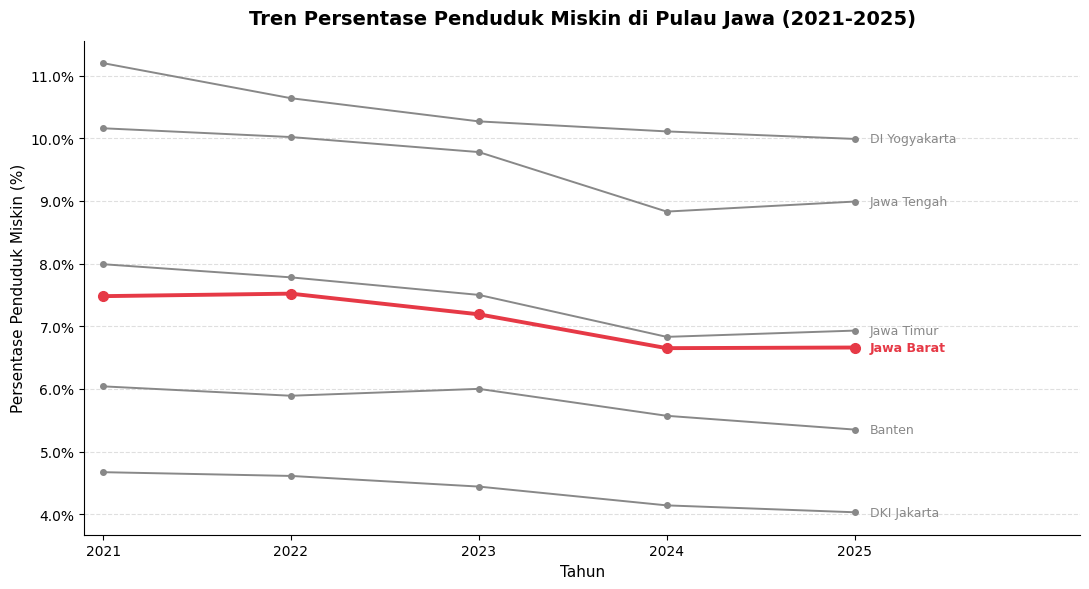

In [15]:
df_plot = ppo_jawa.set_index('Provinsi').T
df_plot.index = df_plot.index.astype(int)

PROV_STYLE = {
    'JAWA BARAT'    : ('Jawa Barat',    '#E63946', 2.8, 7, 5),
    'DI YOGYAKARTA' : ('DI Yogyakarta', '#888888', 1.4, 4, 2),
    'JAWA TENGAH'   : ('Jawa Tengah',   '#888888', 1.4, 4, 2),
    'JAWA TIMUR'    : ('Jawa Timur',    '#888888', 1.4, 4, 2),
    'BANTEN'        : ('Banten',        '#888888', 1.4, 4, 2),
    'DKI JAKARTA'   : ('DKI Jakarta',   '#888888', 1.4, 4, 2),
}

fig, ax = plt.subplots(figsize=(11, 6))

for prov, (label, color, lw, ms, zo) in PROV_STYLE.items():
    is_jabar = prov == 'JAWA BARAT'
    ax.plot(df_plot.index, df_plot[prov],
            color=color, linewidth=lw, marker='o',
            markersize=ms, zorder=zo)
    ax.text(
        df_plot.index[-1] + 0.08, df_plot[prov].iloc[-1],
        label, color=color, fontsize=9, va='center',
        fontweight='bold' if is_jabar else 'normal',
    )

ax.set_title(
    'Tren Persentase Penduduk Miskin di Pulau Jawa (2021-2025)',
    fontsize=14, fontweight='bold', pad=12,
)
ax.set_xlabel('Tahun', fontsize=11)
ax.set_ylabel('Persentase Penduduk Miskin (%)', fontsize=11)
ax.set_xticks(df_plot.index)
ax.set_xlim(df_plot.index[0] - 0.1, df_plot.index[-1] + 1.2)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'g1_tren.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

#### Wawasan

> Secara keseluruhan, seluruh provinsi di Pulau Jawa mencatat penurunan angka kemiskinan dari 2021 ke 2025, meskipun beberapa provinsi mengalami fluktuasi di tengah periode. Jawa Tengah dan Jawa Timur bahkan mencatat sedikit kenaikan di tahun 2025, mengindikasikan bahwa pemulihan pasca 2021 tidak bersifat linier. Jawa Barat berada di posisi menengah dengan kisaran 6,65-7,52%, di bawah DI Yogyakarta dan Jawa Tengah yang konsisten di atas 8%, tetapi lebih tinggi dibandingkan DKI Jakarta dan Banten.

---

# Grafik 2: Peta Sebaran Kemiskinan Jawa Barat 2025 <a name="6"></a>

---

Peta koropleth ini menampilkan tingkat kemiskinan di setiap kabupaten/kota Jawa Barat pada 2025. Batas wilayah menggunakan data GADM 4.1 yang dibaca dengan `geopandas`. Wilayah tanpa padanan data (Pangandaran tidak tercakup dalam GADM 4.1 dan Waduk Cirata merupakan badan air) ditampilkan dalam abu-abu.

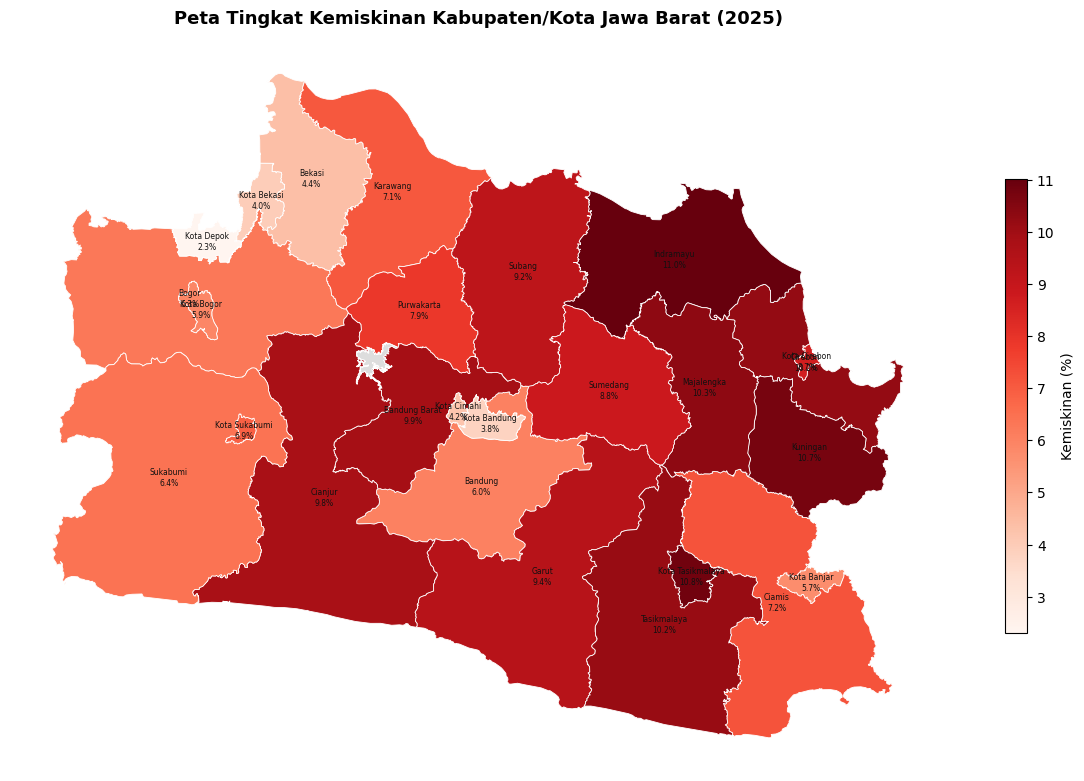

In [16]:
gdf = gpd.read_file(CLEAN_DIR + 'gadm41_IDN_2.json')
gdf_jabar = gdf[gdf['NAME_1'] == 'JawaBarat'].copy()

gdf_jabar = gdf_jabar.merge(
    jabar[['gadm_name', 'region', 'type', 'poverty_rate']],
    left_on='NAME_2', right_on='gadm_name',
    how='left',
)

fig, ax = plt.subplots(figsize=(12, 8))
gdf_jabar.plot(
    column='poverty_rate',
    cmap='Reds',
    linewidth=0.6,
    edgecolor='white',
    legend=True,
    legend_kwds={'label': 'Kemiskinan (%)', 'orientation': 'vertical', 'shrink': 0.6},
    missing_kwds={'color': '#DDDDDD', 'label': 'Tidak ada data'},
    ax=ax,
)

for _, row in gdf_jabar.iterrows():
    if pd.notna(row.get('poverty_rate')):
        c = row.geometry.centroid
        region = row['region']
        label  = region if row['type'] == 'Kota' else region.replace('Kota ', '')
        ax.annotate(
            f"{label}\n{row['poverty_rate']:.1f}%",
            xy=(c.x, c.y), ha='center', va='center',
            fontsize=5.5, color='#111111',
            linespacing=1.3,
        )

ax.set_title(
    'Peta Tingkat Kemiskinan Kabupaten/Kota Jawa Barat (2025)',
    fontsize=13, fontweight='bold', pad=12,
)
ax.axis('off')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'g2_peta.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

#### Wawasan

> Kemiskinan di Jawa Barat terkonsentrasi di bagian selatan dan timur. Kabupaten Indramayu, Kuningan, Majalengka, dan Tasikmalaya memperlihatkan angka kemiskinan tertinggi yang melampaui 10%. Sebaliknya, kota-kota di koridor utara seperti Kota Depok, Kota Bekasi, dan Kota Bandung mencatat tingkat kemiskinan terendah di bawah 5%, mencerminkan konsentrasi aktivitas ekonomi formal di kawasan tersebut.

---

# Grafik 3: Korelasi Kemiskinan dan Pengangguran 2025 <a name="7"></a>

---

Grafik pencar ini menguji hubungan antara persentase penduduk miskin dan tingkat pengangguran terbuka (TPT) di 27 kabupaten/kota Jawa Barat pada 2025. Kota dan Kabupaten dibedakan dengan warna berbeda, dan garis regresi linier ditampilkan untuk masing-masing kelompok.

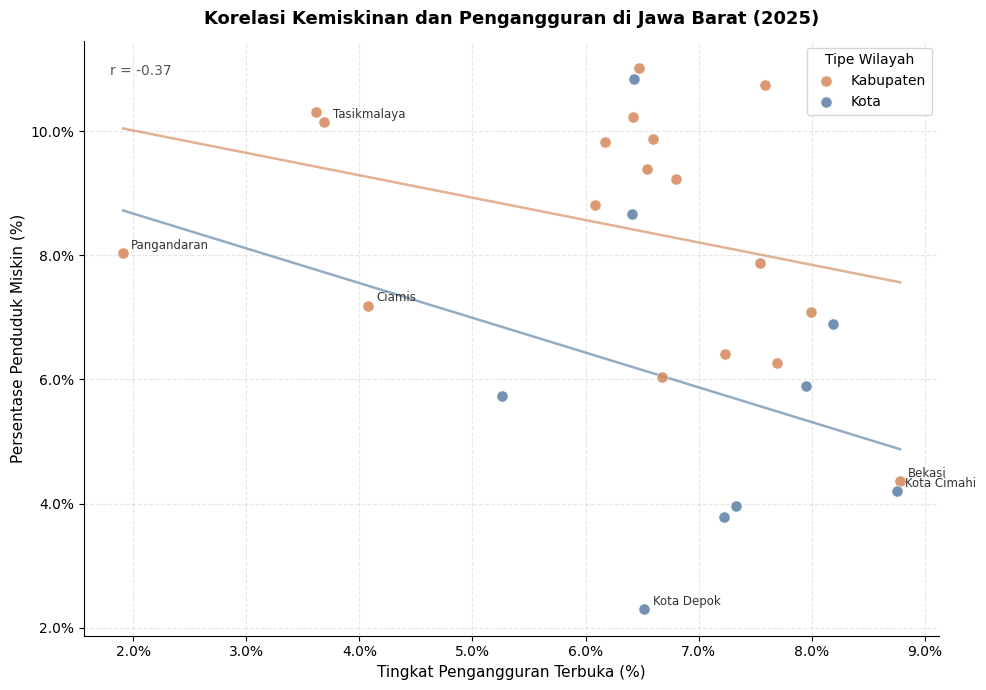

In [17]:
COLOR_MAP = {'Kota': '#5B7FA6', 'Kabupaten': '#D4875A'}

fig, ax = plt.subplots(figsize=(10, 7))

for t, grp in jabar.groupby('type'):
    ax.scatter(
        grp['unemployment_rate'], grp['poverty_rate'],
        color=COLOR_MAP[t], s=65, alpha=0.85,
        edgecolors='white', linewidths=0.5,
        label=t, zorder=3,
    )
    slope, intercept, *_ = stats.linregress(
        grp['unemployment_rate'], grp['poverty_rate']
    )
    xl = np.linspace(jabar['unemployment_rate'].min(),
                     jabar['unemployment_rate'].max(), 100)
    ax.plot(xl, slope * xl + intercept,
            color=COLOR_MAP[t], linewidth=1.8, alpha=0.65)

for _, row in jabar[jabar['region'].isin(ANOMALI_ALL)].iterrows():
    ax.annotate(
        row['region'],
        xy=(row['unemployment_rate'], row['poverty_rate']),
        xytext=(6, 3), textcoords='offset points',
        fontsize=8.5, color='#333333',
    )

r, _ = stats.pearsonr(jabar['unemployment_rate'], jabar['poverty_rate'])
ax.text(0.03, 0.96, f'r = {r:.2f}', transform=ax.transAxes,
        fontsize=10, va='top', color='#555555')

ax.set_title(
    'Korelasi Kemiskinan dan Pengangguran di Jawa Barat (2025)',
    fontsize=13, fontweight='bold', pad=12,
)
ax.set_xlabel('Tingkat Pengangguran Terbuka (%)', fontsize=11)
ax.set_ylabel('Persentase Penduduk Miskin (%)', fontsize=11)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))
ax.legend(title='Tipe Wilayah', frameon=True, fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'g3_scatter.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

#### Wawasan

> Korelasi antara kemiskinan dan pengangguran di Jawa Barat lemah dan negatif (r = -0.37), menunjukkan bahwa tingginya pengangguran tidak selalu sejalan dengan tingginya kemiskinan. Kabupaten Pangandaran, Tasikmalaya, dan Ciamis memiliki tingkat pengangguran yang sangat rendah tetapi angka kemiskinan tinggi di Jawa Barat, mengindikasikan bahwa pekerjaan yang tersedia di kawasan tersebut belum mampu mengangkat daya beli masyarakat.

---

# Grafik 4: Kota-Kota Anomali Jawa Barat 2025 <a name="8"></a>

---

Untuk menguji apakah garis kemiskinan menjelaskan anomali, setiap wilayah anomali dipetakan ke dua persentil secara bersamaan: persentil TPT dan persentil garis kemiskinan relatif terhadap 27 wilayah Jawa Barat. Apabila garis kemiskinan memang menjadi penyebab anomali, wilayah dengan TPT rendah seharusnya memiliki garis kemiskinan yang tinggi pula, dan sebaliknya. Kemiringan garis setiap wilayah langsung memperlihatkan apakah hipotesis itu terkonfirmasi atau tidak.

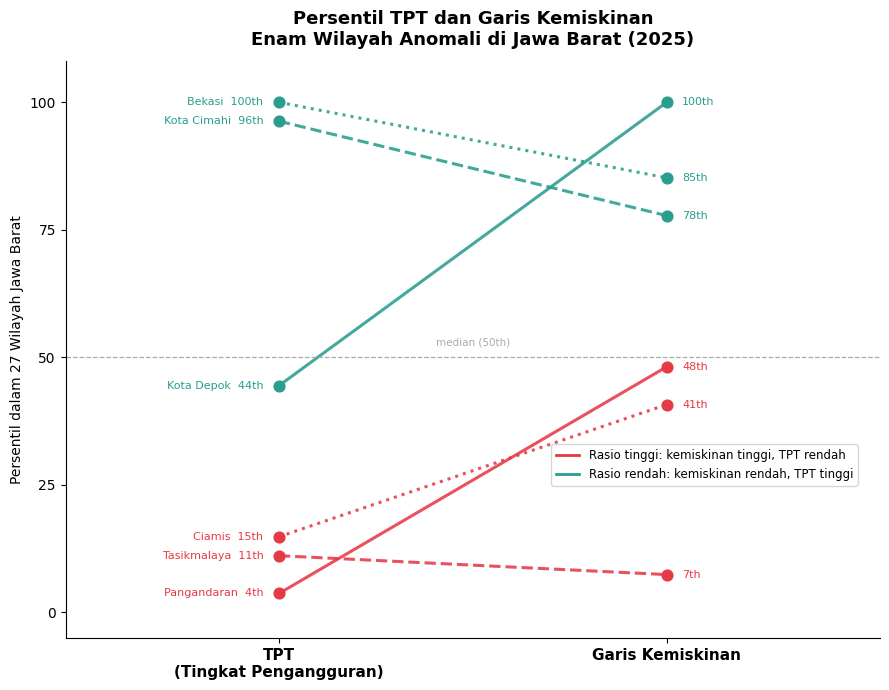

In [18]:
jabar['tpt_pct'] = jabar['unemployment_rate'].rank(pct=True) * 100
jabar['gk_pct']  = jabar['poverty_level'].rank(pct=True) * 100

anomali = jabar[jabar['region'].isin(ANOMALI_ALL)].copy()

C_HIGH = '#E63946'
C_LOW  = '#2A9D8F'
STYLES = ['-', '--', ':']

fig, ax = plt.subplots(figsize=(9, 7))

for grp, color in [(ANOMALI_HIGH, C_HIGH), (ANOMALI_LOW, C_LOW)]:
    subset = anomali[anomali['region'].isin(grp)].sort_values('tpt_pct')
    for i, (_, row) in enumerate(subset.iterrows()):
        tpt, gk = row['tpt_pct'], row['gk_pct']
        ax.plot([0, 1], [tpt, gk], color=color, lw=2.2,
                ls=STYLES[i], alpha=0.88)
        ax.scatter([0, 1], [tpt, gk], color=color, s=60, zorder=5)
        ax.text(-0.04, tpt, f"{row['region']}  {tpt:.0f}th",
                ha='right', va='center', fontsize=8, color=color)
        ax.text(1.04, gk, f"{gk:.0f}th",
                ha='left', va='center', fontsize=8, color=color)

ax.axhline(50, color='#AAAAAA', lw=0.9, ls='--')
ax.text(0.5, 52, 'median (50th)', ha='center', va='bottom',
        fontsize=7.5, color='#AAAAAA')

from matplotlib.lines import Line2D
legend_el = [
    Line2D([0],[0], color=C_HIGH, lw=2,
           label='Rasio tinggi: kemiskinan tinggi, TPT rendah'),
    Line2D([0],[0], color=C_LOW,  lw=2,
           label='Rasio rendah: kemiskinan rendah, TPT tinggi'),
]
ax.legend(handles=legend_el, loc='center right',
          bbox_to_anchor=(0.98, 0.3), fontsize=8.5, frameon=True)

ax.set_xticks([0, 1])
ax.set_xticklabels(['TPT\n(Tingkat Pengangguran)', 'Garis Kemiskinan'],
                   fontsize=11, fontweight='bold')
ax.set_xlim(-0.55, 1.55)
ax.set_ylim(-5, 108)
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_ylabel('Persentil dalam 27 Wilayah Jawa Barat', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.set_title(
    'Persentil TPT dan Garis Kemiskinan\n'
    'Enam Wilayah Anomali di Jawa Barat (2025)',
    fontsize=13, fontweight='bold', pad=12,
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'g4_slopegraph.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

#### Wawasan

> Tiga wilayah rasio tinggi (merah) memiliki TPT di persentil terbawah tetapi garis kemiskinan yang hanya berada di kisaran menengah ke bawah. Garis mereka condong ke atas atau relatif datar, artinya garis kemiskinan tidak tinggi sehingga hipotesis biaya hidup tidak terkonfirmasi. Kemiskinan tinggi di sini bukan karena standar subsisten yang mahal, melainkan karena upah sektor pertanian memang rendah secara absolut.

> Tiga wilayah rasio rendah (hijau) memiliki garis kemiskinan di persentil tertinggi, jauh di atas persentil TPT mereka. Garis mereka menanjak tajam ke kanan, mengonfirmasi bahwa tingginya standar biaya hidup memang berkorelasi dengan rendahnya kemiskinan meski penganggurannya tinggi.